In [2]:
# Autoreload modules
%load_ext autoreload
%autoreload 2

import pylupnt as pnt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Regions of Interest

In [2]:
# Regions of interest (permanently shadowed regions)
regions_psr_df = pd.read_excel('data/permanently-shadowed-regions.xlsx')
lats_psr = regions_psr_df["Cent. Lat."].values
lons_psr = regions_psr_df["Cent. Long."].values - 180
areas_psr = regions_psr_df["Area (km2)"].values
coverage_psr = regions_psr_df["Coverage (%)"].values
alts_psr = np.zeros_like(lats_psr)
regions_psr_df.head()

,PSR ID,Cent. Lat.,Cent. Long.,Area (km2),Perimeter (km),Features of Interest,Lunar Features,Coverage (%),Data Quality
0,SP_896450_1282030,-89.645,128.203,233.698,70.32,"2012-258 (M1102304370R): 129.549, -89.632 (S80...",Shackleton Crater,65,1.0
1,SP_895060_2806850,-89.506,280.685,53.262,45.48,NaN,de Gerlache Crater Shackleton Crater,0,NaN
2,SP_890390_3377770,-89.039,337.777,60.358,54.24,NaN,Haworth Crater Shackleton Crater,0,NaN
3,SP_889970_3170870,-88.997,317.087,44.284,49.56,NaN,de Gerlache Crater Haworth Crater,0,NaN
4,SP_889970_0191990,-88.997,19.199,55.408,36.84,NaN,Haworth Crater Shackleton Crater,10,1.0


In [3]:
# Regions of interest (impact craters)
regions_ic_df = pd.read_excel(
    "data/Lunar_Impact_Crater_Database_v08Sep2015.xls", sheet_name="Database"
)
regions_ic_df = regions_ic_df[regions_ic_df["3. Latitude [°]"] <= 90]
lats_ic = regions_ic_df["3. Latitude [°]"].values
lons_ic = regions_ic_df["4. Longitude [°]"].values
areas_ic = np.pi * np.square(regions_ic_df["6. Radius [km]"].values)
alts_ic = np.zeros_like(lats_ic)
regions_ic_df.head()

,1. Crater name,2. Diameter [km],3. Latitude [°],4. Longitude [°],5. East longitude [°],6. Radius [km],7. Radius [m],8. Apparent diameter [km],9. Transient cavity diameter [km],10. Transient cavity diameter [km],...,73. Average CF [μm],74. Average OMAT,75. Average FeO [wt.-%],76. OMAT range,77. Plg abundance class,78. Province,79. Peak degradation,80. PAN location,81. Rays,1. Crater name .1
0,Abbe,63.98,-57.58,174.77,174.77,31.990,31990.0,55.0228,51.469659,37.371461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe
1,Abbe H,25.13,-58.44,177.58,177.58,12.565,12565.0,21.6118,23.258264,15.604124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe H
2,Abbe K,26.10,-59.82,176.86,176.86,13.050,13050.0,22.4460,24.019177,16.166327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe K
3,Abbe M,28.61,-61.75,175.24,175.24,14.305,14305.0,24.6046,25.968919,17.614889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbe M
4,Abbot,10.40,5.56,54.74,54.74,5.200,5200.0,8.6320,8.736000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abbot


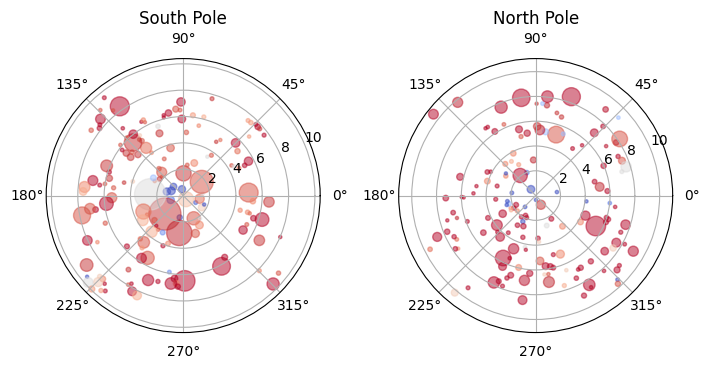

In [4]:
plot_scale = 0.5
fig_scale = 0.02

fig = plt.figure(figsize=(360 * fig_scale, 180 * fig_scale))
# Polar plot (South pole)
ax = fig.add_subplot(121, polar=True)
idxs = lats_psr < 0
ax.scatter(
    np.radians(lons_psr[idxs]),
    90 + lats_psr[idxs],
    c=coverage_psr[idxs],
    cmap="coolwarm",
    s=areas_psr[idxs] * plot_scale,
    alpha=0.5,
)
plt.title("South Pole")

# Polar plot (North pole)
ax = fig.add_subplot(122, polar=True)
idxs = lats_psr > 0
ax.scatter(
    np.radians(lons_psr[idxs]),
    90 - lats_psr[idxs],
    c=coverage_psr[idxs],
    cmap="coolwarm",
    s=areas_psr[idxs] * plot_scale,
    alpha=0.5,
)
plt.title("North Pole")
plt.tight_layout()
plt.show()

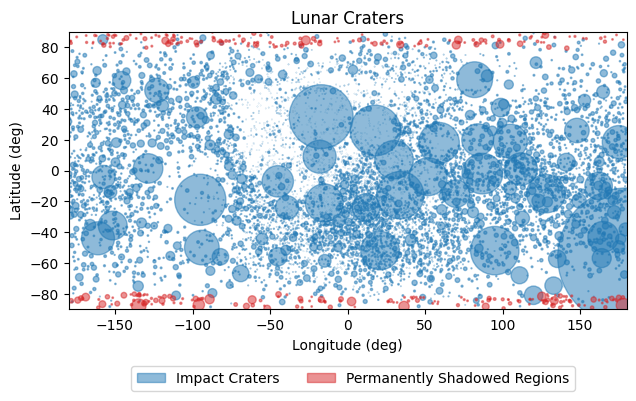

In [5]:
plot_scale = 0.002
fig_scale = 0.02
plt.figure(figsize=(360 * fig_scale, 180 * fig_scale))
plt.scatter(lons_ic, lats_ic, s=areas_ic * plot_scale, alpha=0.5, c="tab:blue")
plt.scatter(
    lons_psr,
    lats_psr,
    c="tab:red",
    s=areas_psr * plot_scale * 50,
    alpha=0.5,
)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Lunar Craters")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
p1 = plt.Circle((0, 0), 90, color="tab:blue", alpha=0.5)
p2 = plt.Circle((0, 0), 90, color="tab:red", alpha=0.5)
plt.legend(
    [p1, p2],
    ["Impact Craters", "Permanently Shadowed Regions"],
    loc="center left",
    ncol=2,
    bbox_to_anchor=(0.1, -0.25),
)
plt.show()

In [3]:
fig = pnt.plots.Plot3D()
fig.plot_surface("MOON", scale=3)

AttributeError: module 'pylupnt' has no attribute 'plots'